# Week 10 (Module 21) - BBO capstone driver

Round 10. Three rounds left after this one (W11, W12 dress rehearsal, then final locks). Every query serves the endgame: verify what's banked, chase live signal, hold the rest steady.

**Plan:**
- **f1 -> perpendicular probe (0.385, 0.511)**: the three readings so far bracket the hot spot along one line (strongest at (0.41, 0.47)); this closes in from the other axis.
- **f2 -> tight refine** near the new 0.682 winner (first improvement in nine weeks - is there more?).
- **f3 -> AEI conservative**.
- **f4 -> EXACT RE-SUBMIT of the W2 winner (repro test)**: +/-0.01 cost 0.23 last week while +/-0.02 cost only 0.03 the week before - loss doesn't track distance, so either razor-rugged or noisy. If 0.5401 doesn't reproduce, the banked value was partly luck and we need the remaining weeks to react.
- **f5 -> space_fill** (peak banked; exploration free).
- **f6 -> tiny step, fresh direction** (basin is locally flat - map its edge).
- **f7 -> tiny step, fresh direction** (W9's direction sloped down; try another).
- **f8 -> MES** (three consecutive marginal nudges - keep collecting).


In [ ]:
%matplotlib inline
import os, sys, warnings
warnings.filterwarnings("ignore")
_root = os.getcwd()
while not os.path.exists(os.path.join(_root, "bo.py")) and os.path.dirname(_root) != _root:
    _root = os.path.dirname(_root)
os.chdir(_root); sys.path.insert(0, _root)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bo

WEEK = 10
SEED = 10
rng = np.random.default_rng(SEED)
OUTDIR = f"outputs/week{WEEK:02d}"; os.makedirs(OUTDIR, exist_ok=True)

results = {}

# f1: perpendicular probe from the strongest reading.
f1_x = np.array([0.385000, 0.511000])
results[1] = dict(x=f1_x, u=f1_x, submission=bo.format_submission(f1_x),
                  acq="llm_probe", mean=float('nan'), std=float('nan'),
                  incumbent_y=0.0, n_data=len(bo.load(1)[1]))

# f4: exact re-submit of the W2 winner - reproduction test.
f4_x = np.array([0.409370, 0.417326, 0.352834, 0.435452])
m4 = bo.fit(4)
results[4] = dict(x=f4_x, u=bo.to_unit(f4_x.reshape(1,-1), m4.b).reshape(-1),
                  submission=bo.format_submission(f4_x), acq="repro_test",
                  mean=float('nan'), std=float('nan'), incumbent_y=0.5401,
                  n_data=len(bo.load(4)[1]), model=m4)

def tight_refine(fid, scale, clamp=None):
    X, y, d = bo.load(fid); b = bo.bounds(fid, d)
    x_best = X[int(np.argmax(y))]
    pert = rng.normal(0, scale, size=d)
    if clamp: pert = np.clip(pert, -clamp, clamp)
    x_new = np.clip(x_best + pert, 0.0, 0.999999)
    m = bo.fit(fid)
    mean, std = m.predict(bo.to_unit(x_new.reshape(1,-1), b))
    return dict(x=x_new, u=bo.to_unit(x_new.reshape(1,-1), b).reshape(-1),
               submission=bo.format_submission(x_new), acq="tight_refine",
               mean=float(mean[0]), std=float(std[0]), incumbent_y=float(y.max()),
               n_data=len(y), model=m)

results[2] = tight_refine(2, scale=0.02)
results[6] = tight_refine(6, scale=0.015)
results[7] = tight_refine(7, scale=0.015)

GP_PLAN = {3: dict(acq="aei", xi=0.10), 5: dict(acq="space_fill"), 8: dict(acq="mes")}
for fid, plan in GP_PLAN.items():
    results[fid] = bo.run_function(fid, seed=SEED, **plan)

for fid in bo.FUNC_IDS:
    bo.validate_submission(results[fid]["submission"], len(results[fid]["x"]))

pd.DataFrame([dict(func=f"f{fid}", source=results[fid]["acq"],
                   incumbent=round(results[fid]["incumbent_y"], 4),
                   submission=results[fid]["submission"]) for fid in bo.FUNC_IDS])


## 1. Data - seed the working CSVs and review the function descriptions

In [2]:
bo.seed_csvs()          # data/f1..f8.csv from initial_data/*.npy (no-op once they exist)
bo.write_descriptions() # data/function_descriptions.csv
pd.read_csv("data/function_descriptions.csv")[["func", "dims", "n_seed", "character", "application"]]

,func,dims,n_seed,character,application
0,1,2,10,Sparse/flat (mostly ~0 except near sources); m...,Radiation/contamination source detection in a ...
1,2,2,10,Noisy + multimodal with many local peaks.,Mystery ML model returning a noisy log-likelih...
2,3,3,15,Maximise a negated cost (toward 0).,Drug discovery: combinations of three compound...
3,4,4,30,Dynamic with many local optima.,Warehouse product-placement surrogate; output ...
4,5,4,20,"Typically unimodal, a single peak.",Chemical-process yield.
5,6,5,20,Negative-by-design; maximise toward 0.,Cake recipe with five ingredients; combined ne...
6,7,6,30,Black-box; literature priors can inform the se...,"ML hyperparameter tuning (lr, reg, #layers...)..."
7,8,8,40,High-dimensional; global optimisation hard.,"8-param ML hyperparameter tuning (lr, batch, l..."


## 2. Fit a surrogate and propose the next query for all 8 functions

In [3]:
results = {fid: bo.run_function(fid, kind=KIND, seed=SEED, **PLAN[fid]) for fid in bo.FUNC_IDS}

summary = pd.DataFrame([
    dict(func=f"f{fid}", d=len(results[fid]["x"]), n_data=results[fid]["n_data"],
         incumbent_y=round(results[fid]["incumbent_y"], 4),
         pred_mean=round(results[fid]["mean"], 4),
         pred_std=round(results[fid]["std"], 4),
         acq_used=results[fid]["acq"], submission=results[fid]["submission"])
    for fid in bo.FUNC_IDS
])
summary

,func,d,n_data,incumbent_y,pred_mean,pred_std,acq_used,submission
0,f1,2,11,0.0000,-0.0003,0.0011,var,0.496189-0.999917
1,f2,2,11,0.6112,0.6096,0.0460,thompson,0.693032-0.021807
2,f3,3,16,-0.0348,-0.0990,0.0978,ucb,0.292949-0.004902-0.659805
3,f4,4,31,0.2596,0.4304,0.1879,ei,0.409370-0.417326-0.352834-0.435452
4,f5,4,21,1616.6257,1621.4181,53.7076,ei,0.999999-0.999999-0.999999-0.999999
5,f6,5,21,-0.7143,-0.5689,0.2917,ucb,0.485805-0.358911-0.999999-0.999999-0.000000
6,f7,6,31,1.3650,1.1672,0.1792,ucb,0.000000-0.114089-0.014952-0.152330-0.346297-0...
7,f8,8,41,9.5985,10.0720,0.1263,mes,0.092741-0.076176-0.211705-0.000000-0.999999-0...


### Acquisition values at each proposed point
All four acquisitions are computed every round so the choice can be justified in the reflection.

In [4]:
pd.DataFrame([
    dict(func=f"f{fid}", **{k: round(v, 4) for k, v in results[fid]["acq_all"].items()})
    for fid in bo.FUNC_IDS
])

,func,ei,ucb,pi,var
0,f1,0.0000,0.0018,0.0000,0.0000
1,f2,0.0131,0.7016,0.4001,0.0021
2,f3,0.0126,0.1944,0.2241,0.0096
3,f4,0.1812,0.8061,0.8039,0.0353
4,f5,23.9023,1728.8333,0.5355,2884.5066
5,f6,0.1964,0.3063,0.6786,0.0851
6,f7,0.0109,1.7049,0.1232,0.0321
7,f8,0.4635,10.3246,0.9999,0.0159


## 3. Visualise
2D functions get full posterior + acquisition heatmaps; higher-D functions get 1D slices
through the incumbent. Every function gets convergence + leave-one-out diagnostics.

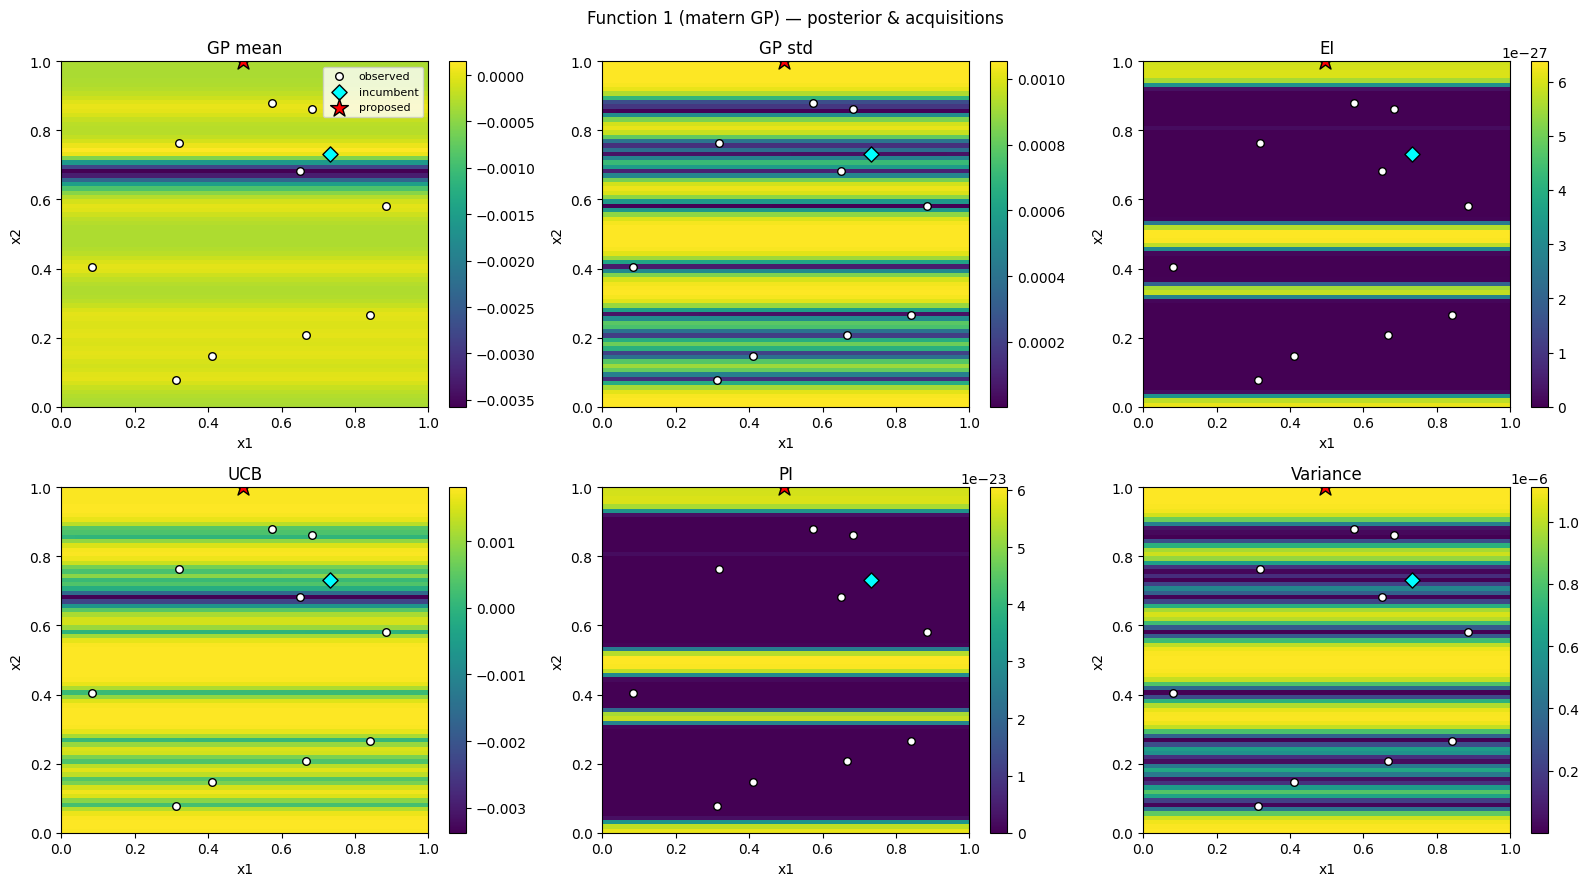

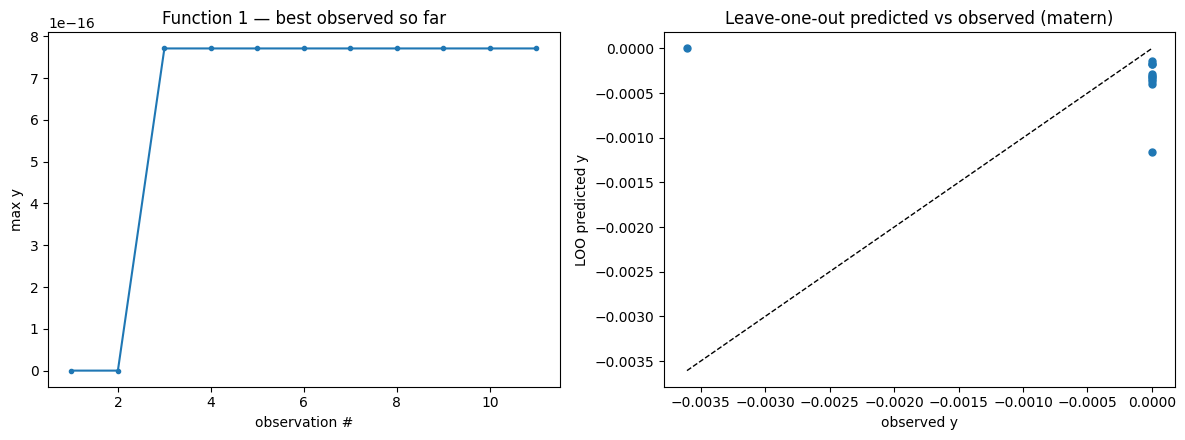

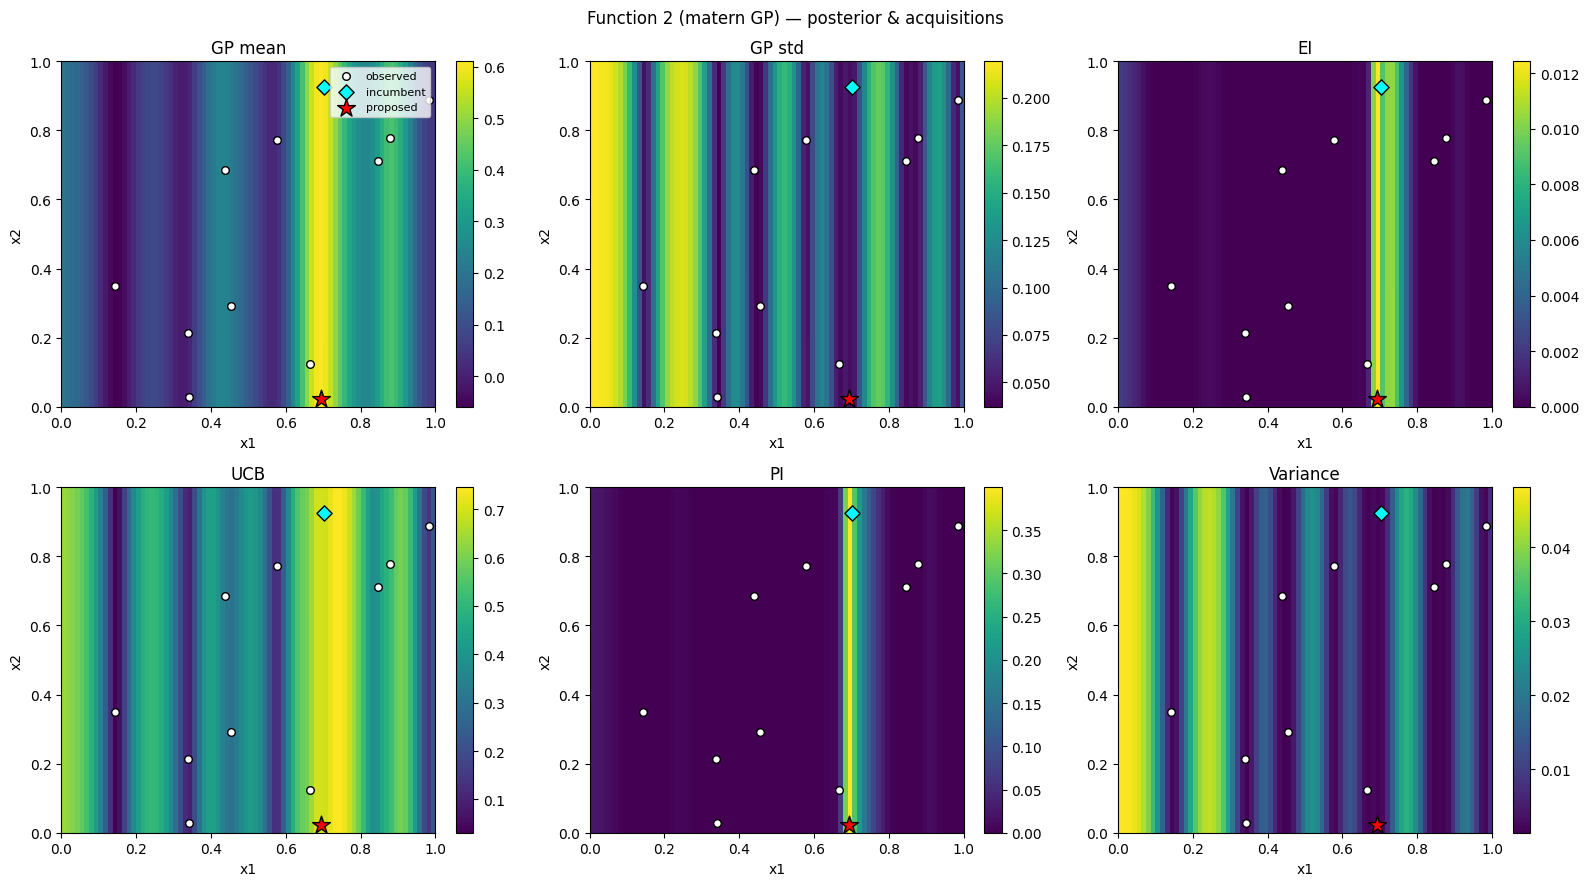

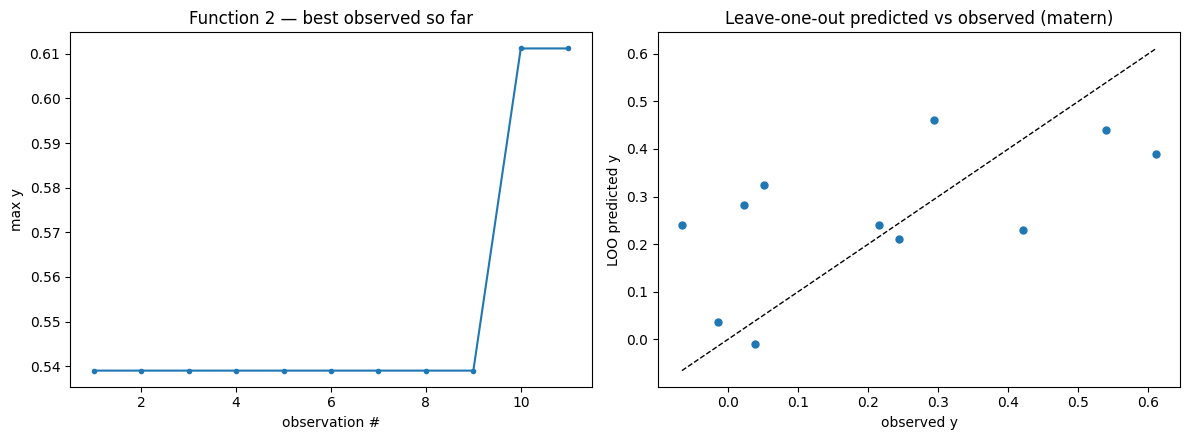

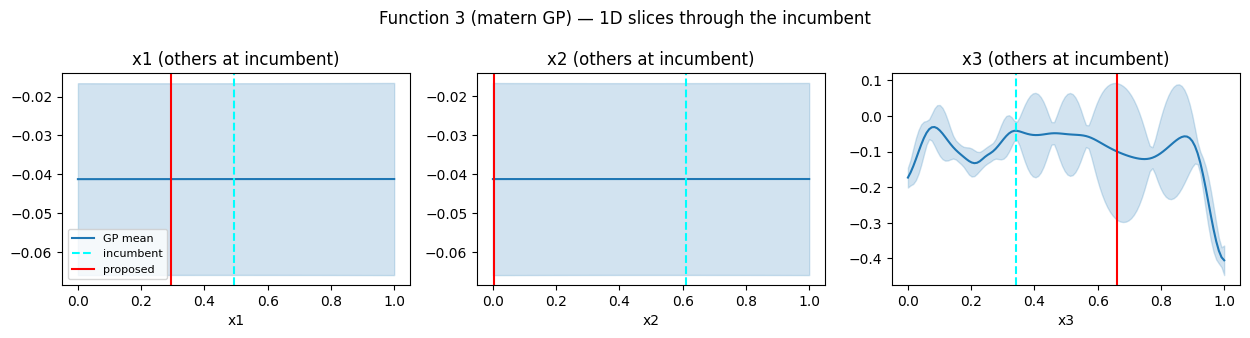

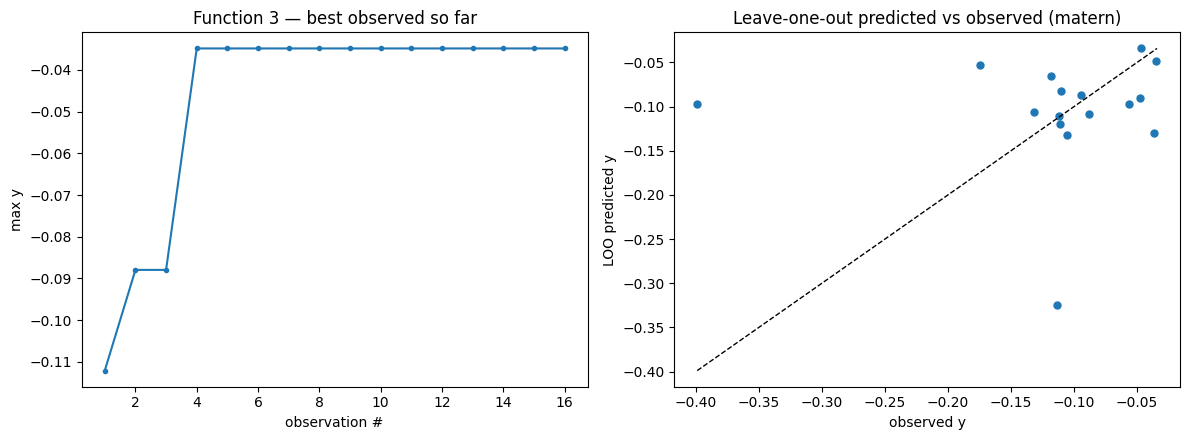

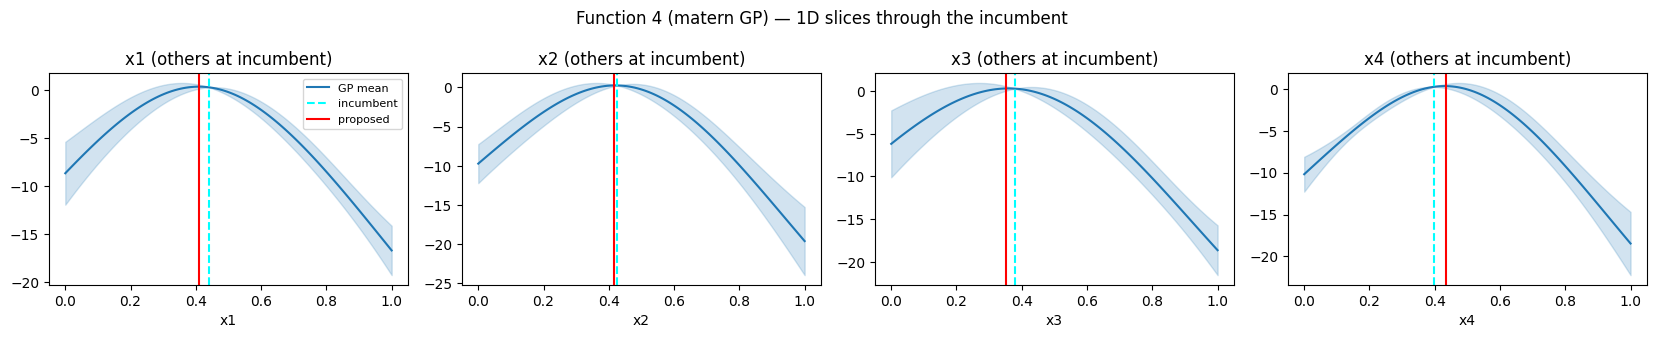

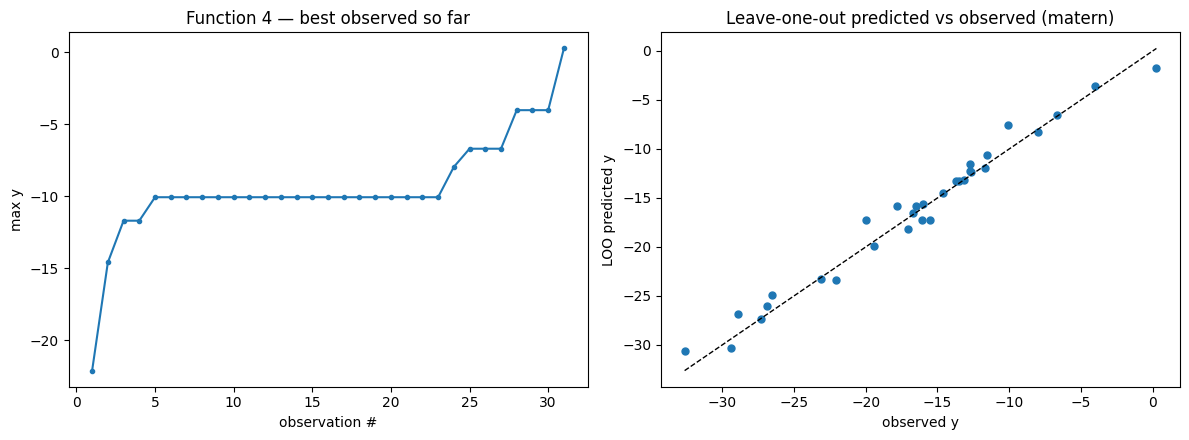

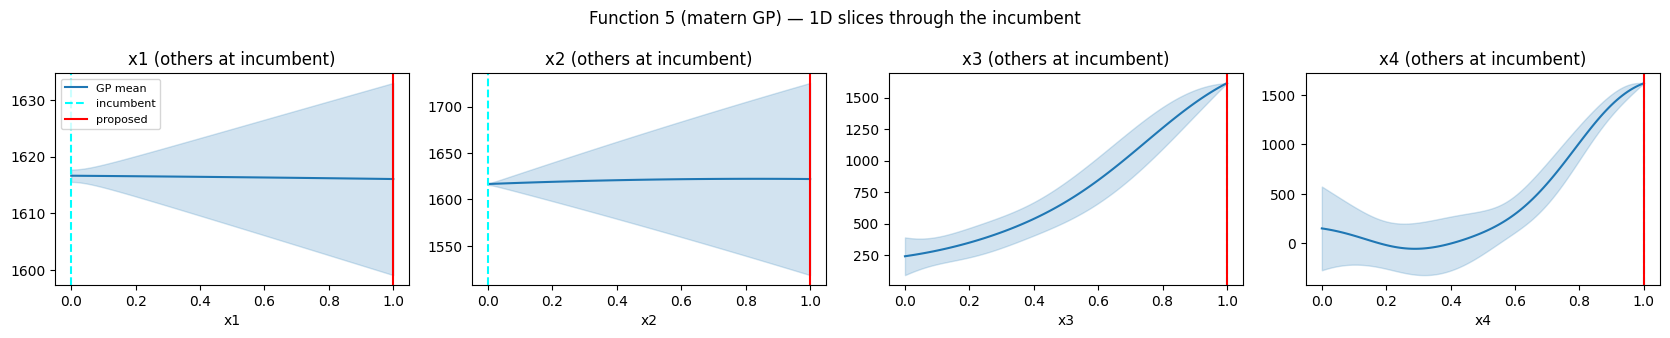

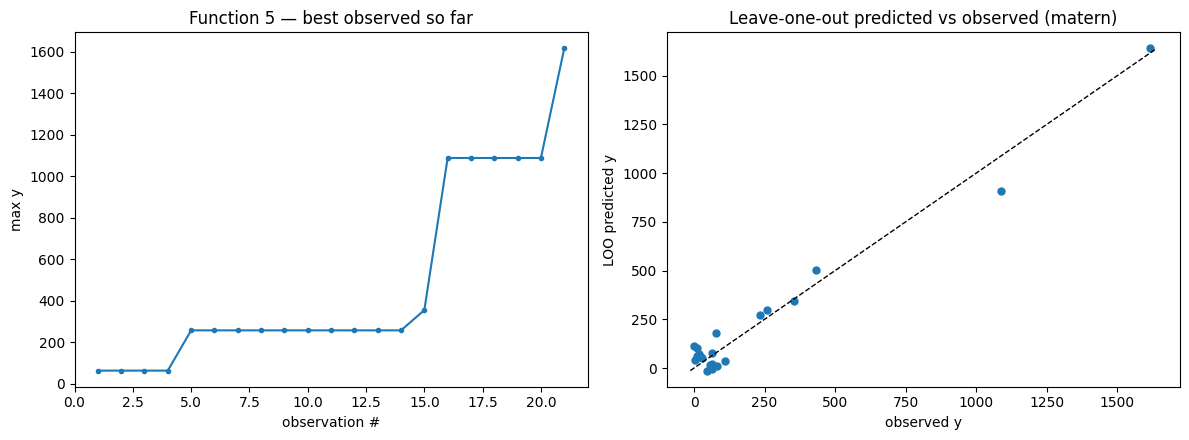

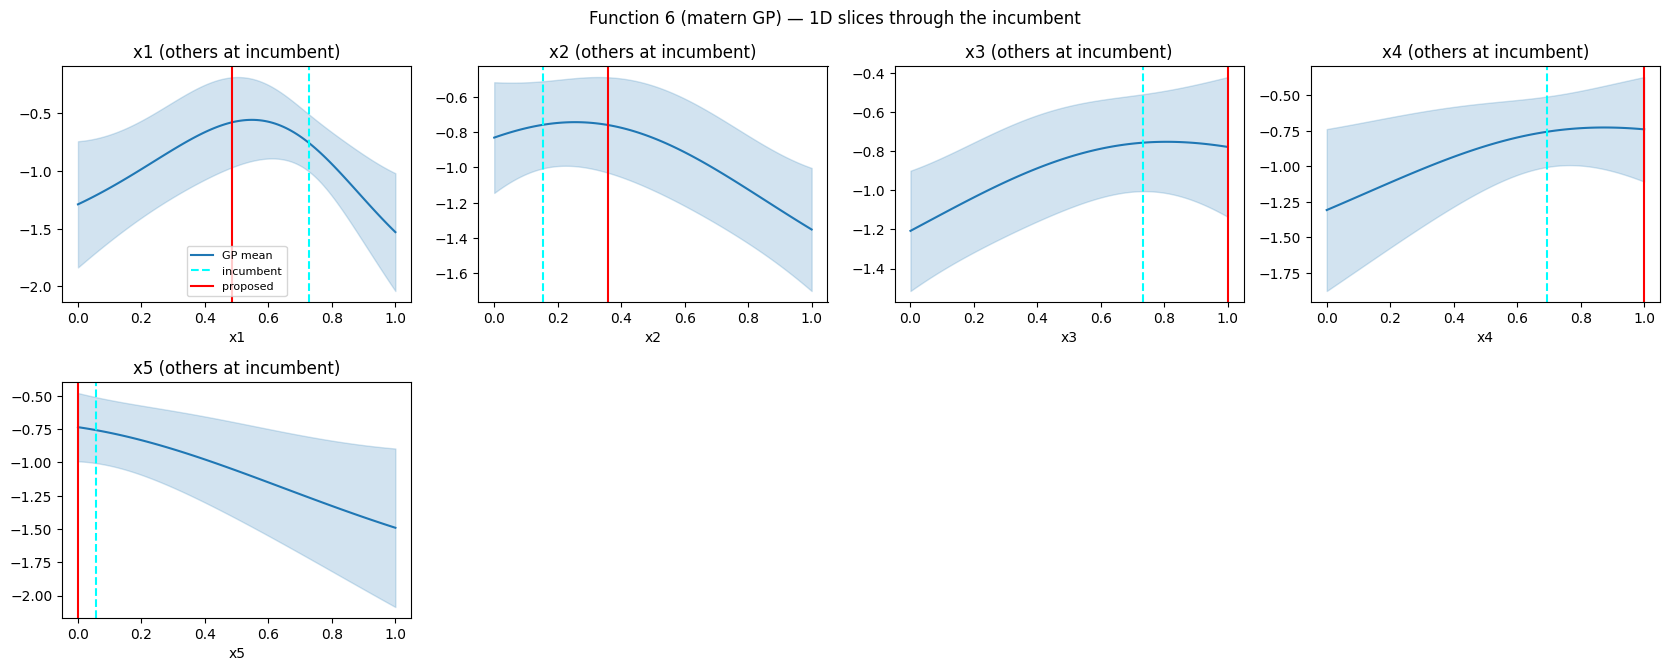

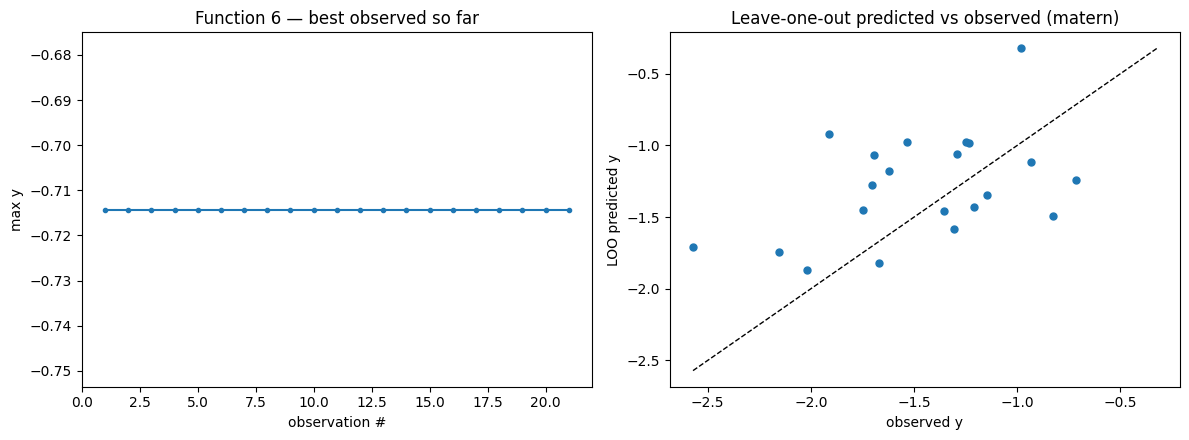

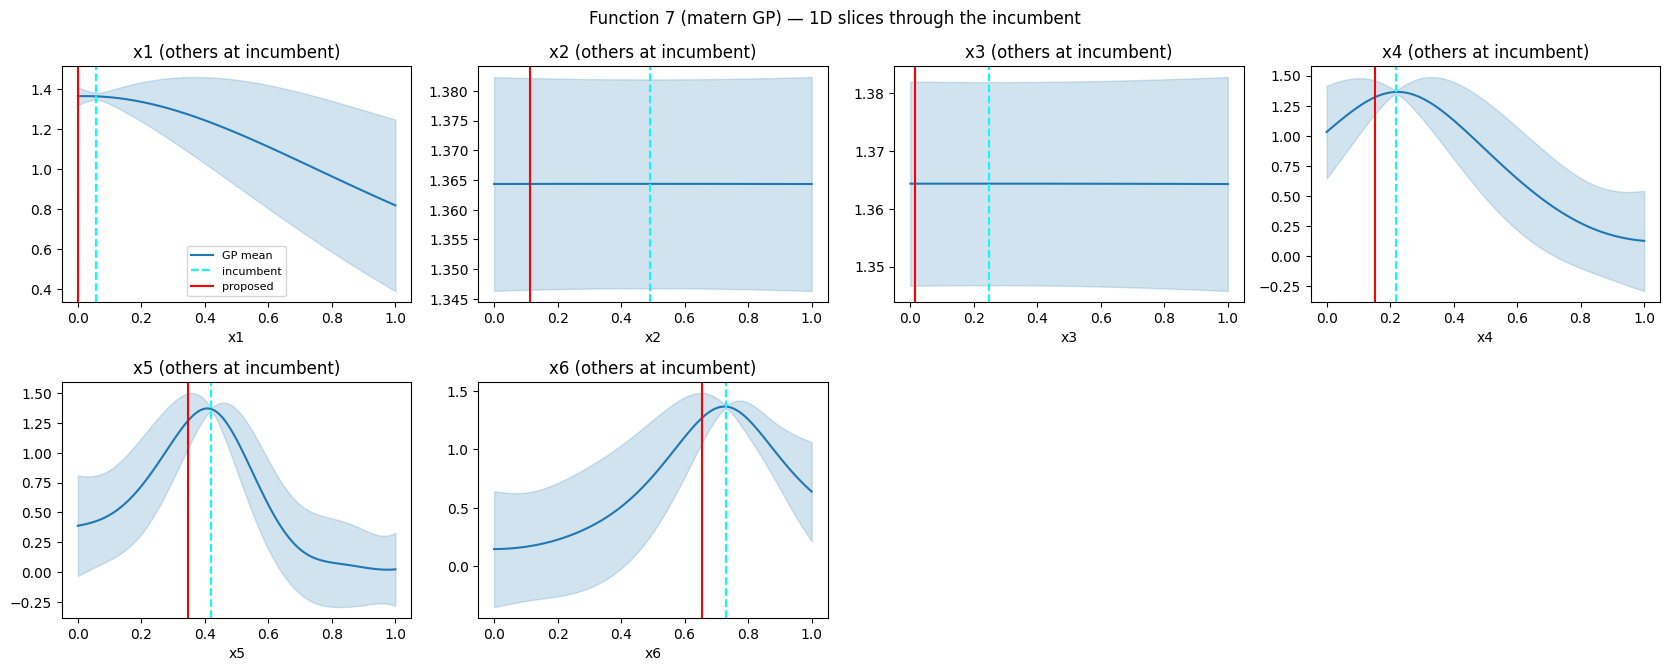

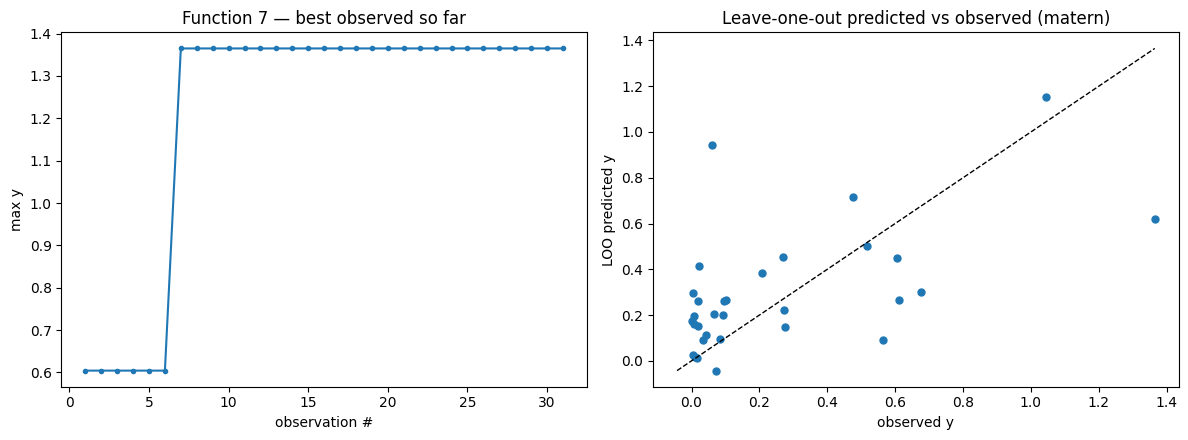

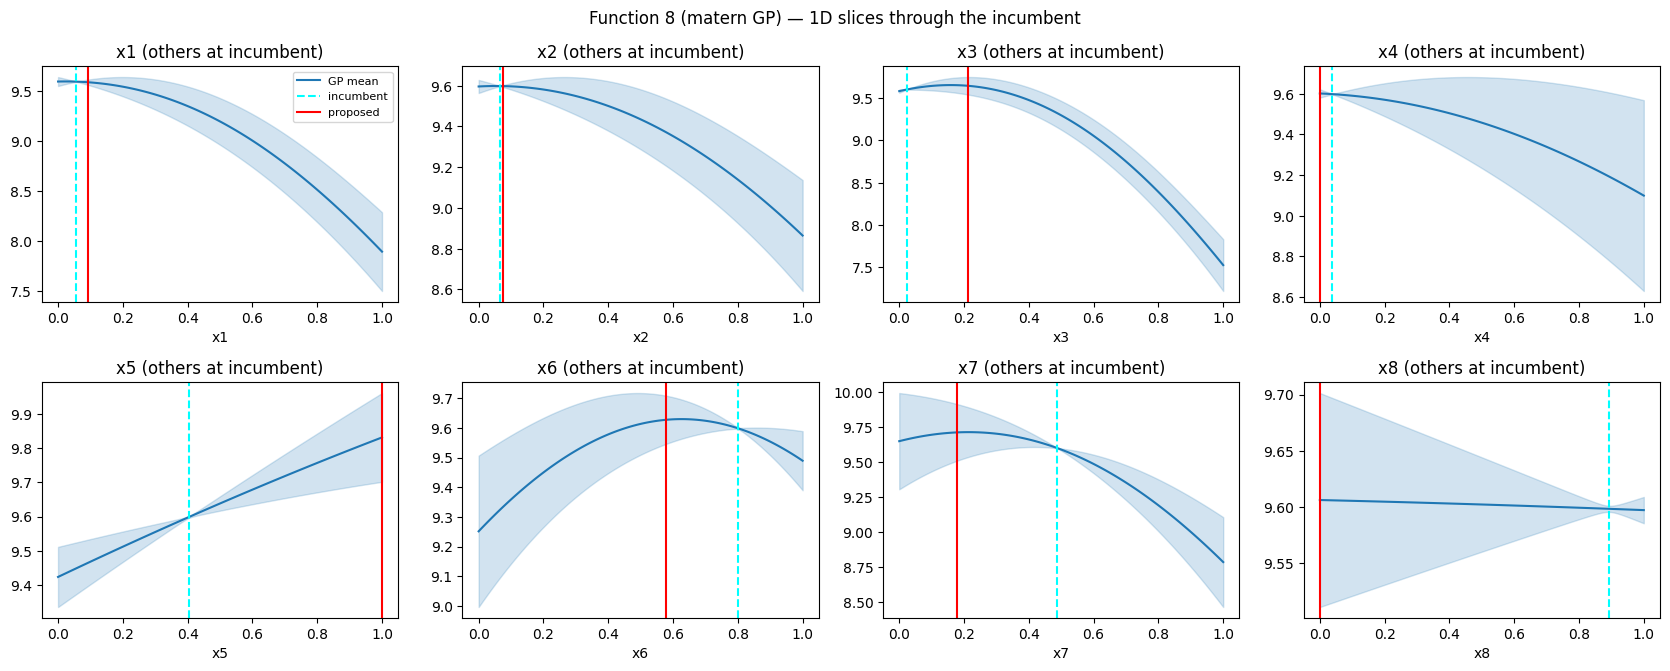

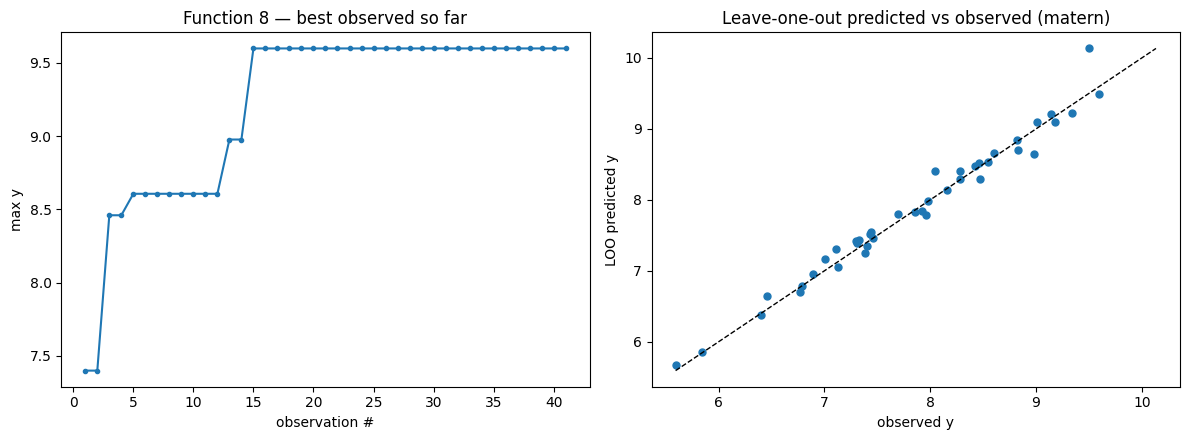

In [5]:
for fid in bo.FUNC_IDS:
    r = results[fid]; m = r["model"]
    beta = PLAN[fid].get("beta", 2.0); xi = PLAN[fid].get("xi", 0.01)
    if m.d == 2:
        bo.plot_2d(m, beta=beta, xi=xi, proposed=r["x"], save=f"{OUTDIR}/f{fid}_2d.png")
    else:
        bo.plot_slices(m, beta=beta, xi=xi, proposed_u=r["u"], save=f"{OUTDIR}/f{fid}_slices.png")
    bo.plot_diagnostics(m, save=f"{OUTDIR}/f{fid}_diag.png")
    plt.show()

## 4. Submission strings - copy one per function into the portal

In [6]:
for fid in bo.FUNC_IDS:
    print(f"f{fid}:  {results[fid]['submission']}")

f1:  0.496189-0.999917
f2:  0.693032-0.021807
f3:  0.292949-0.004902-0.659805
f4:  0.409370-0.417326-0.352834-0.435452
f5:  0.999999-0.999999-0.999999-0.999999
f6:  0.485805-0.358911-0.999999-0.999999-0.000000
f7:  0.000000-0.114089-0.014952-0.152330-0.346297-0.654022
f8:  0.092741-0.076176-0.211705-0.000000-0.999999-0.576902-0.178640-0.000000


## 5. Write the weekly reflection scaffold
Creates `weekly/reflections/weekNN.md` if it doesn't exist yet. It will **not** overwrite a
reflection you've already written (pass `overwrite=True` to force a fresh scaffold).

In [7]:
path = bo.render_reflection(WEEK, results)
print("reflection ->", path)

reflection -> /Users/jp/PycharmProjects/MachineLearning/Capstone/weekly/reflections/week02.md


## 6. After the portal returns each y - record results for next round
Fill in the returned outputs below, run the cell, then bump `WEEK` and re-run the notebook
next module. `append_result` grows each function's CSV by one row.

In [ ]:
# After the portal returns Week 10's scores, paste them in below and run.
# returned_y = {1: ..., 2: ..., 3: ..., 4: ..., 5: ..., 6: ..., 7: ..., 8: ...}
# for fid, y in returned_y.items():
#     bo.append_result(fid, results[fid]["x"], y)
# print("saved; dataset sizes now:", {fid: len(bo.load(fid)[1]) for fid in bo.FUNC_IDS})
